In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import os
from PIL import Image
import copy
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

import torch.optim as optim

import cv2 
import copy
import time
%matplotlib inline

# Load data

In [3]:
df = pd.read_csv('/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')
df

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


In [4]:
le = LabelEncoder()
dx_encoded = le.fit_transform(df['dx'])
df['dx_encoded'] = dx_encoded

# EDA

**Only images will be used for classification.**

In [5]:
df['dx_encoded'].value_counts()

dx_encoded
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64

**We have a class imbalance**

Plan
1. Resnet(18/152), EfficientNet(b0/b7), EfficientNetV2(s/l), VisionTransformer(b_16/h_14), SwinTransformer(t/v2_b) with gradual unfreeze\learning rate decay without oversampling\weighted loss
2. add weighted loss
3. add oversampling
4. Compare training\inference time, accuracy
5. add table feature

ResNeXt101_64, 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['image_id',	'age',	'sex',	'localization']], 
    df['dx_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['dx']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, 
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [7]:
part_1 = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
part_2 = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2'

part_1_files = [os.path.join(part_1, f) for f in os.listdir(part_1) if os.path.getsize(os.path.join(part_1, f)) > 0 and f.endswith('.jpg')]
part_2_files = [os.path.join(part_2, f) for f in os.listdir(part_2) if os.path.getsize(os.path.join(part_2, f)) > 0 and f.endswith('.jpg')]

all_files = part_1_files + part_2_files

In [8]:
df_all_files_img = pd.DataFrame({'dir_img':all_files})
df_all_files_img['image_id'] = df_all_files_img['dir_img'].apply(lambda x: x.split('/')[5].split('.')[0])
df_all_files_img

,dir_img,image_id
0,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,ISIC_0028933
1,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,ISIC_0028394
2,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,ISIC_0027799
3,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,ISIC_0028100
4,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,ISIC_0027960
...,...,...
10010,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,ISIC_0029733
10011,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,ISIC_0033470
10012,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,ISIC_0032153
10013,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,ISIC_0030216


In [9]:
X_train_img = list(X_train.merge(df_all_files_img,
                            how='inner',
                            on='image_id')['dir_img'])

X_val_img = list(X_val.merge(df_all_files_img,
                            how='inner',
                            on='image_id')['dir_img'])

X_test_img = list(X_test.merge(df_all_files_img,
                            how='inner',
                            on='image_id')['dir_img'])

# Function for auto training

In [10]:
#Create dataset
class SkinDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [11]:
def get_transforms(model_name: str, strong_aug: bool = True):
    model_name = model_name.lower()
    bicubic = transforms.InterpolationMode.BICUBIC
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    # input size vit_b_16, vit_h_14 also 224 (memory error if 384 and 518)
    if model_name in ['resnet18','resnet152','efficientnet_b0','vit_b_16', 'vit_h_14', 'swin_t', 'swin_b']:
        size = 224
    elif model_name == "efficientnet_b7":
        size = 600
    elif model_name == "efficientnetv2_s":
        size = 384
    elif model_name == "efficientnetv2_l":
        size = 480
    else:
        size = 224

    # aug
    train_tfms = [
        transforms.RandomResizedCrop(size, interpolation=bicubic),
        transforms.RandomHorizontalFlip()
    ]
    if strong_aug:
        train_tfms.append(transforms.ColorJitter(0.4, 0.4, 0.4, 0.1))
    train_tfms.extend([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    train_transform = transforms.Compose(train_tfms)

    val_test_transform = transforms.Compose([
        transforms.Resize(int(size * 1.15), interpolation=bicubic),
        transforms.CenterCrop(size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    return train_transform, val_test_transform

In [12]:
def build_model(model_type: str, num_classes: int, pretrained=True, device="cpu"):
    model_type = model_type.lower()

    if model_type == "resnet18":
        model = models.resnet18(weights="IMAGENET1K_V1" if pretrained else None)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_type == "resnet152":
        model = models.resnet152(weights="IMAGENET1K_V1" if pretrained else None)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_type == "efficientnet_b0":
        model = models.efficientnet_b0(weights="IMAGENET1K_V1" if pretrained else None)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_type == "efficientnet_b7":
        model = models.efficientnet_b7(weights="IMAGENET1K_V1" if pretrained else None)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_type == "efficientnetv2_s":
        model = models.efficientnet_v2_s(weights="IMAGENET1K_V1" if pretrained else None)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_type == "efficientnetv2_l":
        model = models.efficientnet_v2_l(weights="IMAGENET1K_V1" if pretrained else None)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_type == "vit_b_16":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_SWAG_LINEAR_V1 if pretrained else None)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)

    elif model_type == "vit_h_14":
        model = models.vit_h_14(weights=models.ViT_H_14_Weights.IMAGENET1K_SWAG_LINEAR_V1 if pretrained else None)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)

    elif model_type == "swin_t":
        model = models.swin_t(weights="IMAGENET1K_V1" if pretrained else None)
        in_features = model.head.in_features
        model.head = nn.Linear(in_features, num_classes)

    elif model_type == "swin_b":
        model = models.swin_b(weights="IMAGENET1K_V1" if pretrained else None)
        in_features = model.head.in_features
        model.head = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unknown model type: {model_type}")

    model = model.to(device)

    # === freeze ===
    for param in model.parameters():
        param.requires_grad = False

    # === unfreeze fc ===
    if hasattr(model, "fc"):
        for p in model.fc.parameters():
            p.requires_grad = True
    elif hasattr(model, "classifier"):
        for p in model.classifier.parameters():
            p.requires_grad = True
    elif hasattr(model, "heads"):
        for p in model.heads.parameters():
            p.requires_grad = True
    elif hasattr(model, "head"):
        for p in model.head.parameters():
            p.requires_grad = True

    return model

In [13]:
def train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer, 
                patience=5, unfreeze_fn=None, model_type=None, 
                device="cpu", scheduler=None, name_for_save='best_model'):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    best_val_accuracy = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    iter_without_improvements = 0

    model.to(device)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # If need unfreeze
        if unfreeze_fn is not None:
            unfreeze_fn(model, model_type, epoch, optimizer)

        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for images, labels in tqdm(train_loader, desc="Train"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_accuracy = correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Val"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_loss /= total
        val_accuracy = correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        print(f"Train loss: {train_loss:.4f}, acc: {train_accuracy:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_accuracy:.4f}")

        # === Scheduler ===
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # === Early stopping ===
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            iter_without_improvements = 0
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            iter_without_improvements += 1
            if iter_without_improvements > patience:
                print("Early stopping")
                break

    model.load_state_dict(best_model_wts)
    torch.save(model, f"{name_for_save}.pth")
    return model, train_losses, train_accuracies, val_losses, val_accuracies

In [14]:
def gradual_unfreeze(model, model_type, epoch, optimizer=None, every=5):
    """
    Gradual unfreezing of layers depending on the architecture
    optimizer: If passed, new parameters will be added to the optimizer
    """

    def add_to_optimizer(params, lr):
        if optimizer is not None:
            optimizer.add_param_group({"params": params, "lr": lr})

    if model_type in ["resnet18", "resnet152"]:
        if epoch == every:
            for p in model.layer4.parameters(): p.requires_grad = True
            add_to_optimizer(model.layer4.parameters(), lr=1e-4)
        elif epoch == every * 2:
            for p in model.layer3.parameters(): p.requires_grad = True
            add_to_optimizer(model.layer3.parameters(), lr=1e-4)
        elif epoch == every * 3:
            for p in model.layer2.parameters(): p.requires_grad = True
            add_to_optimizer(model.layer2.parameters(), lr=1e-4)
        elif epoch == every * 4:
            for p in model.layer1.parameters(): p.requires_grad = True
            add_to_optimizer(model.layer1.parameters(), lr=1e-4)

    elif model_type in ["efficientnet_b0", "efficientnet_b7","efficientnetv2_s", "efficientnetv2_l"]:
        if epoch == every:
            for p in model.features[-1].parameters(): p.requires_grad = True
            add_to_optimizer(model.features[-1].parameters(), lr=1e-4)
        elif epoch == every * 2:
            for p in model.features[-2].parameters(): p.requires_grad = True
            add_to_optimizer(model.features[-2].parameters(), lr=1e-4)

    elif model_type in ["vit_b_16","vit_h_14"]:
        if epoch == every:
            for p in model.encoder.layers[-1].parameters(): p.requires_grad = True
            add_to_optimizer(model.encoder.layers[-1].parameters(), lr=1e-4)
        elif epoch == every * 2:
            for p in model.encoder.layers[-2].parameters(): p.requires_grad = True
            add_to_optimizer(model.encoder.layers[-2].parameters(), lr=1e-4)

    elif model_type in ["swin_t", "swin_b"]:
        features = list(model.features)[1:]  # пропускаем patch_embed
        if epoch == every:
            for p in features[-1].parameters(): p.requires_grad = True
            add_to_optimizer(features[-1].parameters(), lr=1e-4)
        elif epoch == every * 2:
            for p in features[-2].parameters(): p.requires_grad = True
            add_to_optimizer(features[-2].parameters(), lr=1e-4)

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = 7
criterion = nn.CrossEntropyLoss()
num_epochs = 100
patience = 5

# Training

In [ ]:
models_acr = [#'resnet18', #+
              #'resnet152', #+
              #'efficientnet_b0', #+ 
              #"efficientnet_b7", #+
              #"efficientnetv2_s", #+
              "efficientnetv2_l"
              
              #'vit_h_14', #+ 
              #'swin_t',
              ]
batch_size = 64
for architecture in models_acr:
    train_transforms, val_test_transforms = get_transforms(architecture)
    train_dataset = SkinDataset(X_train_img, list(y_train), transform=train_transforms)
    val_dataset = SkinDataset(X_val_img, list(y_val), transform=val_test_transforms)
    test_dataset = SkinDataset(X_test_img, list(y_test), transform=val_test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4) 

    model = build_model(model_type=architecture, num_classes=num_classes, device=device)
    optimizer = torch.optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    model, train_losses, train_acc, val_losses, val_acc = train_model(
    model, 
    train_loader, 
    val_loader, 
    num_epochs=num_epochs, 
    criterion=criterion, 
    optimizer=optimizer,
    patience=5, 
    unfreeze_fn=lambda m, t, e, opt: gradual_unfreeze(m, t, e, opt),
    model_type=architecture,
    device=device, 
    scheduler=scheduler,
    name_for_save=f"model_{architecture}_base"
)

Downloading: "https://download.pytorch.org/models/vit_h_14_lc_swag-c1eb923e.pth" to /root/.cache/torch/hub/checkpoints/vit_h_14_lc_swag-c1eb923e.pth
100%|██████████| 2.35G/2.35G [00:25<00:00, 97.9MB/s]



Epoch 1/100


Val: 100%|██████████| 13/13 [01:39<00:00,  7.68s/it]


Train loss: 0.8922, acc: 0.6936 | Val loss: 0.6846, acc: 0.7444

Epoch 2/100


Val: 100%|██████████| 13/13 [01:39<00:00,  7.68s/it]


...

Val: 100%|██████████| 13/13 [00:52<00:00,  4.05s/it]


Train loss: 0.5720, acc: 0.7951 | Val loss: 0.3915, acc: 0.8591

Epoch 13/100


Val: 100%|██████████| 13/13 [00:52<00:00,  4.05s/it]


Train loss: 0.5269, acc: 0.8135 | Val loss: 0.3853, acc: 0.8566

Epoch 14/100


Train:  48%|████▊     | 54/113 [05:03<05:28,  5.56s/it]

## ResNet18

In [ ]:
model_resnet18_base = build_model(model_type="resnet18", num_classes=num_classes, device=device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet18_base.parameters()), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

model_resnet18_base, train_losses, train_acc, val_losses, val_acc = train_model(
    model_resnet18_base, 
    train_loader, 
    val_loader, 
    num_epochs=num_epochs, 
    criterion=criterion, 
    optimizer=optimizer,
    patience=5, 
    unfreeze_fn=lambda m, t, e, opt: gradual_unfreeze(m, t, e, opt),
    model_type="resnet18",
    device=device, 
    scheduler=scheduler,
    name_for_save="model_resnet18_base"
)

In [ ]:
# Model training/validation graph
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc)+1), train_acc, label='Train')
plt.plot(range(1, len(val_acc)+1), val_acc, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()

## ResNet152

In [ ]:
model_resnet152_base = build_model(model_type="resnet152", num_classes=num_classes, device=device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet152_base.parameters()), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

model_resnet152_base, train_losses_152_base, train_acc_152_base, val_losses_152_base, val_acc_152_base = train_model(
    model_resnet152_base, 
    train_loader, 
    val_loader, 
    num_epochs=num_epochs, 
    criterion=criterion, 
    optimizer=optimizer,
    patience=5, 
    unfreeze_fn=lambda m, t, e, opt: gradual_unfreeze(m, t, e, opt),
    model_type="resnet152",
    device=device, 
    scheduler=scheduler,
    name_for_save="model_resnet152_base"
)

In [ ]:
# Model training/validation graph
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses_152_base)+1), train_losses_152_base, label='Train')
plt.plot(range(1, len(val_losses_152_base)+1), val_losses_152_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc_152_base)+1), train_acc_152_base, label='Train')
plt.plot(range(1, len(val_acc_152_base)+1), val_acc_152_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()

## efficientnet_b0

In [ ]:
model_effNet_b0_base = build_model(model_type="efficientnet_b0", num_classes=num_classes, device=device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_effNet_b0_base.parameters()), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

model_effNet_b0_base, train_losses_effNet_b0_base, train_acc_effNet_b0_base, val_losses_effNet_b0_base, val_acc_effNet_b0_base = train_model(
    model_effNet_b0_base, 
    train_loader, 
    val_loader, 
    num_epochs=num_epochs, 
    criterion=criterion, 
    optimizer=optimizer,
    patience=5, 
    unfreeze_fn=lambda m, t, e, opt: gradual_unfreeze(m, t, e, opt),
    model_type="efficientnet_b0",
    device=device, 
    scheduler=scheduler,
    name_for_save="model_efficientnet_b0_base"
)

In [ ]:
# Model training/validation graph
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses_effNet_b0_base)+1), train_losses_effNet_b0_base, label='Train')
plt.plot(range(1, len(val_losses_effNet_b0_base)+1), val_losses_effNet_b0_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc_effNet_b0_base)+1), train_acc_effNet_b0_base, label='Train')
plt.plot(range(1, len(val_acc_effNet_b0_base)+1), val_acc_effNet_b0_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()

## efficientnet_b7

In [ ]:
model_effNet_b7_base = build_model(model_type="efficientnet_b7", num_classes=num_classes, device=device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_effNet_b7_base.parameters()), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

model_effNet_b7_base, train_losses_effNet_b7_base, train_acc_effNet_b7_base, val_losses_effNet_b7_base, val_acc_effNet_b7_base = train_model(
    model_effNet_b7_base, 
    train_loader, 
    val_loader, 
    num_epochs=num_epochs, 
    criterion=criterion, 
    optimizer=optimizer,
    patience=5, 
    unfreeze_fn=lambda m, t, e, opt: gradual_unfreeze(m, t, e, opt),
    model_type="efficientnet_b7",
    device=device, 
    scheduler=scheduler,
    name_for_save="model_efficientnet_b7_base"
)

In [ ]:
# Model training/validation graph
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses_effNet_b7_base)+1), train_losses_effNet_b7_base, label='Train')
plt.plot(range(1, len(val_losses_effNet_b7_base)+1), val_losses_effNet_b7_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc_effNet_b7_base)+1), train_acc_effNet_b7_base, label='Train')
plt.plot(range(1, len(val_acc_effNet_b7_base)+1), val_acc_effNet_b7_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()

## efficientnetv2_s

In [ ]:
model_effNetv2_s_base = build_model(model_type="efficientnetv2_s", num_classes=num_classes, device=device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_effNetv2_s_base.parameters()), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

model_effNetv2_s_base, train_losses_effNetv2_s_base, train_acc_effNetv2_s_base, val_losses_effNetv2_s_base, val_acc_effNetv2_s_base = train_model(
    model_effNetv2_s_base, 
    train_loader, 
    val_loader, 
    num_epochs=num_epochs, 
    criterion=criterion, 
    optimizer=optimizer,
    patience=5, 
    unfreeze_fn=lambda m, t, e, opt: gradual_unfreeze(m, t, e, opt),
    model_type="efficientnetv2_s",
    device=device, 
    scheduler=scheduler,
    name_for_save="model_efficientnetv2_s_base"
)

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses_effNetv2_s_base)+1), train_losses_effNetv2_s_base, label='Train')
plt.plot(range(1, len(val_losses_effNetv2_s_base)+1), val_losses_effNetv2_s_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc_effNetv2_s_base)+1), train_acc_effNetv2_s_base, label='Train')
plt.plot(range(1, len(val_acc_effNetv2_s_base)+1), val_acc_effNetv2_s_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()

## efficientnetv2_l

In [ ]:
model_effNetv2_l_base = build_model(model_type="efficientnetv2_l", num_classes=num_classes, device=device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_effNetv2_l_base.parameters()), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

model_effNetv2_l_base, train_losses_effNetv2_l_base, train_acc_effNetv2_l_base, val_losses_effNetv2_l_base, val_acc_effNetv2_l_base = train_model(
    model_effNetv2_l_base, 
    train_loader, 
    val_loader, 
    num_epochs=num_epochs, 
    criterion=criterion, 
    optimizer=optimizer,
    patience=5, 
    unfreeze_fn=lambda m, t, e, opt: gradual_unfreeze(m, t, e, opt),
    model_type="efficientnetv2_l",
    device=device, 
    scheduler=scheduler,
    name_for_save="model_efficientnetv2_l_base"
)

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses_effNetv2_l_base)+1), train_losses_effNetv2_l_base, label='Train')
plt.plot(range(1, len(val_losses_effNetv2_l_base)+1), val_losses_effNetv2_l_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc_effNetv2_l_base)+1), train_acc_effNetv2_l_base, label='Train')
plt.plot(range(1, len(val_acc_effNetv2_l_base)+1), val_acc_effNetv2_l_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()

## VisionTransformer

In [ ]:
model_vit_b_16_base = build_model(model_type="vit_b_16", num_classes=num_classes, device=device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_vit_b_16_base.parameters()), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

model_vit_b_16_base, train_losses_vit_b_16_base, train_acc_vit_b_16_base, val_losses_vit_b_16_base, val_acc_vit_b_16_base = train_model(
    model_vit_b_16_base, 
    train_loader, 
    val_loader, 
    num_epochs=num_epochs, 
    criterion=criterion, 
    optimizer=optimizer,
    patience=5, 
    unfreeze_fn=lambda m, t, e, opt: gradual_unfreeze(m, t, e, opt),
    model_type="vit_b_16",
    device=device, 
    scheduler=scheduler,
    name_for_save="model_vit_b_16_base"
)

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses_vit_b_16_base)+1), train_losses_vit_b_16_base, label='Train')
plt.plot(range(1, len(val_losses_vit_b_16_base)+1), val_losses_vit_b_16_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc_vit_b_16_base)+1), train_acc_vit_b_16_base, label='Train')
plt.plot(range(1, len(val_acc_vit_b_16_base)+1), val_acc_vit_b_16_base, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()

## SWIN

In [ ]:
model_swin_t_base = build_model(model_type="swin_t", num_classes=num_classes, device=device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_swin_t_base.parameters()), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

model_swin_t_base, train_losses_swin_t_base, train_acc_swin_t_base, val_losses_swin_t_base, val_acc_swin_t_base = train_model(
    model_swin_t_base, 
    train_loader, 
    val_loader, 
    num_epochs=num_epochs, 
    criterion=criterion, 
    optimizer=optimizer,
    patience=5, 
    unfreeze_fn=lambda m, t, e, opt: gradual_unfreeze(m, t, e, opt),
    model_type="swin_t",
    device=device, 
    scheduler=scheduler,
    name_for_save="model_swin_t_base"
)

# Metrics

In [ ]:
# Model prediction result
def evaluate_model(model, dataloader, device, class_names=None):
    model.eval()
    y_true, y_pred = [], []
    total_time, num_batches = 0.0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.time()
            outputs = model(images)
            if device.type == "cuda":
                torch.cuda.synchronize()
            end = time.time()

            total_time += (end - start)
            num_batches += 1

            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # --- Метрики
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "avg_batch_time": total_time / num_batches,
        "avg_img_time": (total_time / num_batches) / dataloader.batch_size
    }

    print(f"\n🕒 Avg time per batch: {metrics['avg_batch_time']:.4f} sec")
    print(f"🖼️ Avg time per image: {metrics['avg_img_time']:.4f} sec")

    return metrics, cm, report

# Visualisation confusion matrix
def plot_confusion_matrix(cm, classes):
    with plt.style.context('default'):  
        plt.figure(figsize=(5, 4))
        sns.set(font_scale=1.0)
        sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
                    xticklabels=classes, yticklabels=classes)
        plt.xlabel('Predicted labels')
        plt.ylabel('True labels')
        plt.title('Confusion Matrix')
        plt.show()

In [ ]:
model_resnet18_base = torch.load("/kaggle/input/skin_resnet_18_base/pytorch/default/1/model_resnet18_base.pth",
                   map_location="cpu",
                   weights_only=False)
model_resnet18_base.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _ = model_resnet18_base(images)
        break

metrics, cm, report = evaluate_model(model_resnet18_base, test_loader,device=device)
print("Metrics for current model:")
print(pd.DataFrame([metrics]))
print(report)
plot_confusion_matrix(cm, classes=list(range(num_classes)))

In [ ]:
model_resnet152_base = torch.load("/kaggle/input/skin_resnet152_base/pytorch/default/1/model_resnet152_base.pth",
                   map_location="cpu",
                   weights_only=False)
model_resnet152_base.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _ = model_resnet152_base(images)
        break

metrics, cm, report = evaluate_model(model_resnet152_base, test_loader,device=device)
print("Metrics for current model:")
print(pd.DataFrame([metrics]))
print(report)
plot_confusion_matrix(cm, classes=list(range(num_classes)))

In [ ]:
model_effnet_b0_base = torch.load("/kaggle/input/skin_efficientnet_b0_base/pytorch/default/1/model_efficientnet_b0_base.pth",
                   map_location="cpu",
                   weights_only=False)
model_effnet_b0_base.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _ = model_effnet_b0_base(images)
        break

metrics, cm, report = evaluate_model(model_effnet_b0_base, test_loader,device=device)
print("Metrics for current model:")
print(pd.DataFrame([metrics]))
print(report)
plot_confusion_matrix(cm, classes=list(range(num_classes)))

In [ ]:
model_effnet_b7_base = torch.load("/kaggle/input/skin_efficientnet_b7_base/pytorch/default/1/model_efficientnet_b7_base.pth",
                   map_location="cpu",
                   weights_only=False)
model_effnet_b7_base.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _ = model_effnet_b7_base(images)
        break

metrics, cm, report = evaluate_model(model_effnet_b7_base, test_loader,device=device)
print("Metrics for current model:")
print(pd.DataFrame([metrics]))
print(report)
plot_confusion_matrix(cm, classes=list(range(num_classes)))

In [ ]:
model_effnetV2_s_base = torch.load("/kaggle/input/skin_efficientv2_s_base/pytorch/default/1/model_efficientnetv2_s_base.pth",
                   map_location="cpu",
                   weights_only=False)
model_effnetV2_s_base.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _ = model_effnetV2_s_base(images)
        break

metrics, cm, report = evaluate_model(model_effnetV2_s_base, test_loader,device=device)
print("Metrics for current model:")
print(pd.DataFrame([metrics]))
print(report)
plot_confusion_matrix(cm, classes=list(range(num_classes)))

In [ ]:
model_effnetV2_l_base = torch.load("/kaggle/input/skin_efficientv2_l_base/pytorch/default/1/model_efficientnetv2_l_base.pth",
                   map_location="cpu",
                   weights_only=False)
model_effnetV2_l_base.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _ = model_effnetV2_l_base(images)
        break

metrics, cm, report = evaluate_model(model_effnetV2_l_base, test_loader,device=device)
print("Metrics for current model:")
print(pd.DataFrame([metrics]))
print(report)
plot_confusion_matrix(cm, classes=list(range(num_classes)))

In [ ]:
model_vit_base = torch.load("/kaggle/input/skin_vit_base/pytorch/default/1/model_vit_b_16_base.pth",
                   map_location="cpu",
                   weights_only=False)
model_vit_base.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _ = model_vit_base(images)
        break

metrics, cm, report = evaluate_model(model_vit_base, test_loader,device=device)
print("Metrics for current model:")
print(pd.DataFrame([metrics]))
print(report)
plot_confusion_matrix(cm, classes=list(range(num_classes)))

In [ ]:
model_swin_base = torch.load("/kaggle/input/skin_swin_base/pytorch/default/1/model_swin_t_base.pth",
                   map_location="cpu",
                   weights_only=False)
model_swin_base.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _ = model_swin_base(images)
        break

metrics, cm, report = evaluate_model(model_swin_base, test_loader,device=device)
print("Metrics for current model:")
print(pd.DataFrame([metrics]))
print(report)
plot_confusion_matrix(cm, classes=list(range(num_classes)))

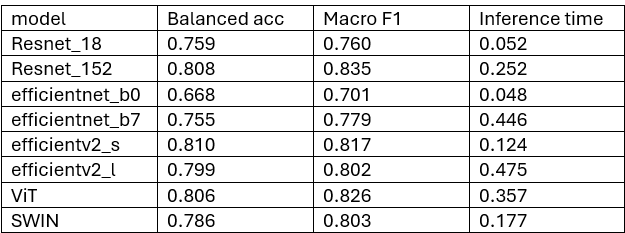
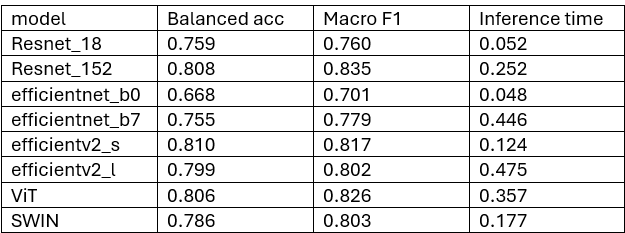